In [902]:
#first, save all the data and into a JSON file

import json

# first data
data1 = [
    {
        "MachineID": "M-301",
        "Temperature_C": 45.2,
        "Vibration_Level": 0.5,
        "Runtime_Hours": 50,
        "FailureRisk": "Low"
    },
    {
        "MachineID": "M-302",
        "Temperature_C": 65.5,
        "Vibration_Level": 1.9,
        "Runtime_Hours": 250,
        "FailureRisk": "High"
    },
    {
        "MachineID": "M-303",
        "Temperature_C": 50.0,
        "Vibration_Level": 1.1,
        "Runtime_Hours": 150,
        "FailureRisk": "Medium"
    },
    {
        "MachineID": "M-304",
        "Temperature_C": 42.1,
        "Vibration_Level": 0.8,
        "Runtime_Hours": 90,
        "FailureRisk": "Low"
    }
]

# Data1.json
with open("Data1.json", "w") as f:
    json.dump(data1, f, indent=4)

In [903]:
data2 = [
    {
        "ReviewID": "P-1",
        "ReviewText": "The quality is amazing, definitely worth the price.",
        "Sentiment": "Positive"
    },
    {
        "ReviewID": "P-2",
        "ReviewText": "Product broke after one week. Extremely disappointed.",
        "Sentiment": "Negative"
    },
    {
        "ReviewID": "P-3",
        "ReviewText": "It was just okay, nothing special but it functions.",
        "Sentiment": "Neutral"
    },
    {
        "ReviewID": "P-4",
        "ReviewText": "Best purchase of the year! Five stars from me.",
        "Sentiment": "Positive"
    }
]

# Data2.json
with open("Data2.json", "w") as f:
    json.dump(data2, f, indent=4)

In [904]:
data3 = [
    {
        "ComponentID": "C-1",
        "Measurement_X": 10.5,
        "Measurement_Y": 4.2,
        "QualityStatus": "Pass"
    },
    {
        "ComponentID": "C-2",
        "Measurement_X": 8.1,
        "Measurement_Y": 7.5,
        "QualityStatus": "Defective"
    },
    {
        "ComponentID": "C-3",
        "Measurement_X": 11.9,
        "Measurement_Y": 3.1,
        "QualityStatus": "Pass"
    },
    {
        "ComponentID": "C-4",
        "Measurement_X": 7.0,
        "Measurement_Y": 9.0,
        "QualityStatus": "Defective"
    }
]

# Save as Data3.json
with open("Data3.json", "w") as f:
    json.dump(data3, f, indent=4)

### DSC1109: Formative Assessment 2

### Exercise 1: Decision Tree - Predicting Equipment Failure Risk

**Concept Focus:** Decision Tree stucture, splitting criteria, and using the max_depth hyperparameter to optimize model complexity. 

**Real-World Scenario:** An industrial plant monitors heavy machinery to predict potential component failure and schedule preventative maintenance.

In [925]:
import json
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron


In [906]:
df1 = pd.read_json("Data1.json")
df1.head()

,MachineID,Temperature_C,Vibration_Level,Runtime_Hours,FailureRisk
0,M-301,45.2,0.5,50,Low
1,M-302,65.5,1.9,250,High
2,M-303,50.0,1.1,150,Medium
3,M-304,42.1,0.8,90,Low


In [907]:
X = df1[["Temperature_C","Vibration_Level","Runtime_Hours"]]
y = df1["FailureRisk"]

In [908]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25, random_state = 42)

In [909]:
modelA_df1 = DecisionTreeClassifier(max_depth=2)
modelA_fit = modelA_df1.fit(X_train, y_train)
modelA_fit

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [910]:
ModelA_pred = modelA_fit.predict(X_test)
print(f"Test Prediction: {ModelA_pred} Test Actual: {y_test.values}")

Test Prediction: ['Medium'] Test Actual: ['High']


In [911]:
ModelA_test_acc = accuracy_score(y_test, ModelA_pred)
print(f"The percentage of the test accuracy for model A (max_depth = 2) is: {ModelA_test_acc *100 }%")

ModelA_train_acc = accuracy_score(y_train, modelA_fit.predict(X_train))
print(f"The percentage of the train accuracy for model A (max_depth = 2) is: {ModelA_train_acc *100 }%")


The percentage of the test accuracy for model A (max_depth = 2) is: 0.0%
The percentage of the train accuracy for model A (max_depth = 2) is: 100.0%


In [912]:
modelB_df1 = DecisionTreeClassifier(max_depth=6)
modelB_fit = modelB_df1.fit(X_train, y_train)
modelB_fit

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [913]:
modelB_pred = modelB_fit.predict(X_test)

print(f"Test Prediction: {modelB_pred} Test Actual: {y_test.values}")

Test Prediction: ['Medium'] Test Actual: ['High']


In [914]:
modelB_test_acc = accuracy_score(y_test, modelB_pred)
print(f"The percentage of the test accuracy for model B (max_depth = 6) is: {modelB_test_acc *100 }%")

modelB_train_acc = accuracy_score(y_train, modelB_fit.predict(X_train))
print(f"The percentage of the train accuracy for model B (max_depth = 6) is: {modelB_train_acc *100 }%")


The percentage of the test accuracy for model B (max_depth = 6) is: 0.0%
The percentage of the train accuracy for model B (max_depth = 6) is: 100.0%


Looking at the results for both, Model A and Model B achieved perfect accuracy on the training data but completely failed on the test data.
This suggests that the models have overfitted, or the model have memorized the training examples instead of understanding the underlying patterns.
Since both models were trained on the same limited dataset, they ended up behaving the same way, producing identical results. Due to this, it may be harder to digress which model is better just because there is limited data to work with.

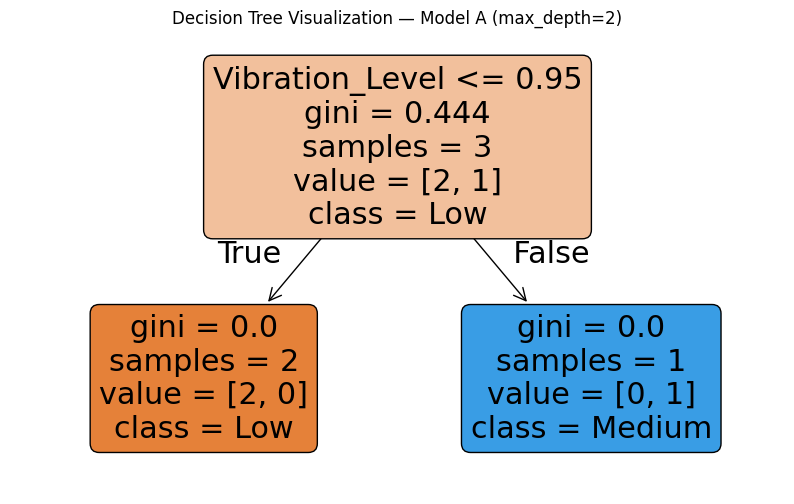

In [915]:
plt.figure(figsize=(10, 6))
plot_tree(
    modelA_df1,
    feature_names=X.columns,
    class_names=[str(c) for c in modelA_df1.classes_],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization — Model A (max_depth=2)")
plt.show()

The visualization shows that Model A relies mainly on the vibration level to determine the failure risk of a machine. When the vibration level is less than or equal to 0.95, the model predicts that the machine has a low risk of failure. On the other hand, when the vibration level exceeds 0.95, it classifies the machine as having a medium risk. The model’s splits are very clear and simple, meaning it focuses on just one key factor to make its predictions. This makes the decision tree easy to interpret and aligns with the idea that higher vibration levels often indicate greater mechanical stress or potential issues.

In [916]:
new_data = [[60, 1.5, 120]] 
expected = "Medium"
prediction = modelA_df1.predict(new_data)

print("Predicted Failure Risk:", prediction[0], "Expected:", expected)

Predicted Failure Risk: Medium Expected: Medium


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Since the model predicted correct, it shows that since the vibratio level, as evident in the visualization, is higher than 0.95, the model classifies the machine as Medium risk. Since the input had a vibration level of 1.5, it naturally followed that rule. Even though temperature and runtime were part of the data, the model didn’t use them in this shallow version (max_depth=2). It focused mainly on vibration level as the key deciding factor. This shows that the simpler model captures a very direct and interpretable relationship.

### Exercise 2: Naive Bayes - Sentiment Analysis for Product Reviews

In [917]:
df2 = pd.read_json("Data2.json")

df2.head()


,ReviewID,ReviewText,Sentiment
0,P-1,"The quality is amazing, definitely worth the p...",Positive
1,P-2,Product broke after one week. Extremely disapp...,Negative
2,P-3,"It was just okay, nothing special but it funct...",Neutral
3,P-4,Best purchase of the year! Five stars from me.,Positive


In [918]:
X = df2["ReviewText"]
y = df2["Sentiment"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
vectorizer = CountVectorizer()

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [919]:
model_df2 = MultinomialNB()
model_df2.fit(X_train_vectorized, y_train)

y_pred = model_df2.predict(X_test_vectorized)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.0

Classification Report:
               precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       0.0
    Positive       0.00      0.00      0.00       2.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [920]:
feature_names = vectorizer.get_feature_names_out()
class_labels = model_df2.classes_
if 'Negative' in class_labels:
    neg_class_index = np.where(class_labels == 'Negative')[0][0]
    neg_word_log_probs = model_df2.feature_log_prob_[neg_class_index]
    top3_neg_indices = np.argsort(neg_word_log_probs)[-3:][::-1]
    top3_neg_words = feature_names[top3_neg_indices]
    print("Top 3 Negative Words:", top3_neg_words)
else:
    print("The 'Negative' class is not present in the training data.")

Top 3 Negative Words: ['week' 'product' 'one']


In [921]:
new_review = ["The item arrived quickly but is completely useless"]

new_review_vec = vectorizer.transform(new_review)

predicted_sentiment = model_df2.predict(new_review_vec)[0]

probabilities = model_df2.predict_proba(new_review_vec)[0]

print("Predicted Sentiment:", predicted_sentiment)


Predicted Sentiment: Neutral


Looking at the predicted sentiment for the 2nd dataset, it shows that the model failed to capture what was supposed to be the correct sentiment. This is due to many reasons. Looking at the top 3 negative words, it shows the words week, product, and one, all of which are not present in the new review. Since the model uses its predicted based on these basis, it is hard for the model to grasp whether or not it is negative. In addition, the model itself is not perfect as it learns common words that are not supposed to be negative. Another reason is that the training data for negative reviews is still quite limited. The model hasn’t seen enough examples of words like “useless,” “broke,” or “poor quality” to strongly associate them with negativity. So when a sentence mixes both good and bad words, the model gets confused.

### Exercise 3: Simple Learner (Perceptron)

In [952]:
df3 = pd.read_json("Data3.json")
df3.head()

,ComponentID,Measurement_X,Measurement_Y,QualityStatus
0,C-1,10.5,4.2,Pass
1,C-2,8.1,7.5,Defective
2,C-3,11.9,3.1,Pass
3,C-4,7.0,9.0,Defective


In [953]:
df3['QualityStatus'] = df3['QualityStatus'].map({'Pass': 1, 'Defective': -1})

X = df3[['Measurement_X', 'Measurement_Y']]
y = df3['QualityStatus']

In [954]:
model_df3 = Perceptron(max_iter=1000, tol=1e-3)
model_df3.fit(X, y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [955]:
weights = model_df3.coef_[0]
bias = model_df3.intercept_[0]
print("Model Weights:", weights)
print("Model Bias:", bias)


Model Weights: [ 4.9 -5.9]
Model Bias: 0.0


In [956]:
new_input = [[9.0, 6.0]]
pred = model_df3.predict(new_input)

predicted_label = 'Pass' if pred[0] == 1 else 'Defective'
print(f"Predicted QualityStatus for X=9.0, Y=6.0 → {predicted_label}")

Predicted QualityStatus for X=9.0, Y=6.0 → Pass


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


Looking at the model, it predicted Pass because, with such a small dataset, the Perceptron couldn’t perfectly separate the two groups. It learned a simple straight-line boundary that slightly favors the ‘Pass’ region, which caused this point (9, 6) to fall on the wrong side. Now, this doesnt entirely mean that the perceptron is not efficient, it is the cause of because the data is so small and is not complete. 

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


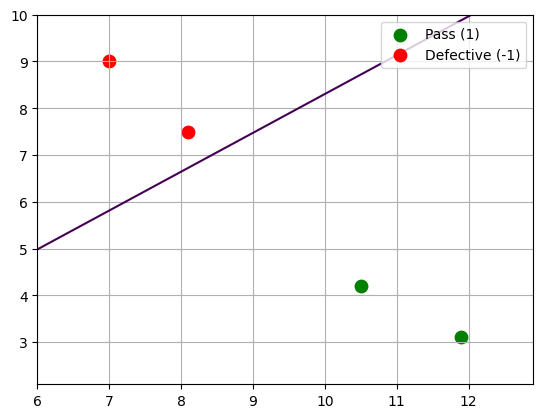

In [962]:

plt.figure()
plt.scatter(df3['Measurement_X'][df3['QualityStatus'] == 1],
            df3['Measurement_Y'][df3['QualityStatus'] == 1],
            color='green', label='Pass (1)', s=80)
plt.scatter(df3['Measurement_X'][df3['QualityStatus'] == -1],
            df3['Measurement_Y'][df3['QualityStatus'] == -1],
            color='red', label='Defective (-1)', s=80)

x_values = np.linspace(df3['Measurement_X'].min()-1, df3['Measurement_X'].max()+1, 100)
y_values = np.linspace(df3['Measurement_Y'].min()-1, df3['Measurement_Y'].max()+1, 100)
xx, yy = np.meshgrid(x_values, y_values)

Z = model_df3.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0])
plt.legend()
plt.grid(True)
plt.show()

The Perceptron tries to draw a straight line that separates “Pass” and “Defective” points in a 2D space. But with only four points, that line is very sensitive to small changes. So even if the new point (9, 6) visually looks closer to the “Defective” examples, the line it learned from such limited data might fall slightly differently, causing it to be classified as “Pass.”